# 발표용 시각 자료 — 4 Figures

작성일: 2026-05-25  
출처: outputs/all_models_comparison_10cls.json, outputs/all_models_comparison_4cls.json, outputs/top4_precision_comparison.json

**Figure 1** (메인): Pitcher Arsenal 정보가 Sequence 모델을 대체할 수 있다 (7-bar, 10-class)  
**Figure 2** (포지셔닝): 3-way 논문 비교 카드  
**Figure 3** (백업): 4-class MDP/DQN 호환 그룹 비교  
**Figure 4** (분석): Top-4 Precision per class — collapse 실체 폭로 히트맵

In [1]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from pathlib import Path

# Korean font
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = Path('../outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

with open(OUTPUT_DIR / 'all_models_comparison_10cls.json', encoding='utf-8') as f:
    comp10 = json.load(f)
with open(OUTPUT_DIR / 'all_models_comparison_4cls.json', encoding='utf-8') as f:
    comp4 = json.load(f)

print('10-class loaded:', list(comp10.keys()))
print('4-class loaded:', list(comp4.keys()))

10-class loaded: ['Logistic Regression', 'LightGBM', 'MLP (10-class)', 'RNN (LSTM)', 'Transformer (Model C)']
4-class loaded: ['Logistic Regression', 'LightGBM', 'MLP (Model B)']


## Figure 1: 핵심 발견 — Pitcher Arsenal이 Sequence를 대체

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_38380\544000051.py:120: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_38380\544000051.py:120: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_38380\544000051.py:121: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.savefig(FIG_DIR / 'fig1_arsenal_vs_sequence.png', dpi=300, bbox_inches='tight',
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_38380\544000051.py:121: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  fig.savefig(FIG_DIR / 'fig1_arsenal_vs_sequence.png', dpi=300, bbox_inches='tight',


C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


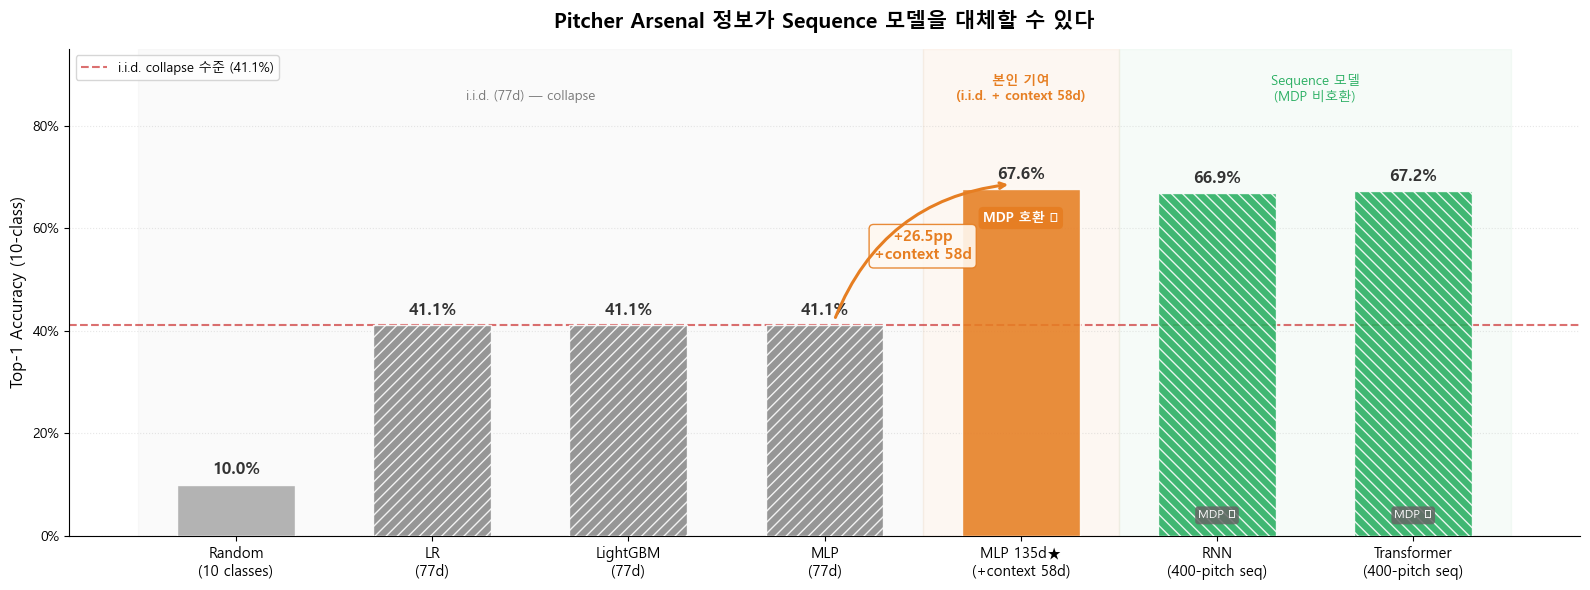

[OK] fig1_arsenal_vs_sequence.png 저장됨


In [2]:
# ── 데이터 ──────────────────────────────────────────────────────────────────
# 논문 비교 기준값 (검증된 실측값)
MODELS = [
    ('Random\n(10 classes)', 0.10),
    ('LR\n(77d)', 0.411),
    ('LightGBM\n(77d)', 0.411),
    ('MLP\n(77d)', 0.411),
    ('MLP 135d★\n(+context 58d)', 0.676),
    ('RNN\n(400-pitch seq)', 0.669),
    ('Transformer\n(400-pitch seq)', 0.672),
]

# 색상 규칙: gray=baseline/i.i.d., orange=context MLP, green=sequence
COLORS = [
    '#aaaaaa',  # Random — 연회색
    '#888888',  # LR — 중간 회색
    '#888888',  # LightGBM
    '#888888',  # MLP 77d
    '#e67e22',  # MLP 135d ★ — 오렌지 (핵심 기여)
    '#27ae60',  # RNN — 초록
    '#27ae60',  # Transformer
]
HATCHES = ['', '///', '///', '///', '', '\\\\\\', '\\\\\\']

names = [m[0] for m in MODELS]
vals  = [m[1] for m in MODELS]

# ── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')

bars = ax.bar(names, vals, color=COLORS, alpha=0.88, width=0.6, zorder=3)
for bar, hatch in zip(bars, HATCHES):
    bar.set_hatch(hatch)
    bar.set_edgecolor('white')

# 값 레이블
for bar, v, c in zip(bars, vals, COLORS):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.012,
        f'{v*100:.1f}%',
        ha='center', va='bottom', fontsize=12, fontweight='bold',
        color='#333333'
    )

# 기준선 (collapse 수준)
ax.axhline(0.411, color='#cc3333', linestyle='--', linewidth=1.5,
           alpha=0.7, zorder=2, label='i.i.d. collapse 수준 (41.1%)')

# 곡선 화살표: MLP 77d (index 3) → MLP 135d (index 4)
x3 = 3  # MLP 77d bar index
x4 = 4  # MLP 135d bar index
ax.annotate(
    '',
    xy=(x4 - 0.05, 0.676 + 0.01),
    xytext=(x3 + 0.05, 0.411 + 0.01),
    arrowprops=dict(
        arrowstyle='->', color='#e67e22', lw=2.2,
        connectionstyle='arc3,rad=-0.3'
    ),
    zorder=10
)
# 화살표 라벨
ax.text(
    3.5, 0.565,
    '+26.5pp\n+context 58d',
    ha='center', va='center', fontsize=11, fontweight='bold',
    color='#e67e22',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff8f0', edgecolor='#e67e22', alpha=0.9)
)

# 검증 박스 (MDP 호환 표시)
ax.text(
    4, 0.62,
    'MDP 호환 ✅',
    ha='center', va='center', fontsize=9.5,
    color='white', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#e67e22', edgecolor='none', alpha=0.95)
)

# Sequence 모델 MDP 비호환 표시
for xi in [5, 6]:
    ax.text(
        xi, 0.04,
        'MDP ❌',
        ha='center', va='center', fontsize=8.5,
        color='white',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#666666', edgecolor='none', alpha=0.85)
    )

# 구분 영역 배경
ax.axvspan(-0.5, 3.5, alpha=0.04, color='#888888', zorder=0)
ax.axvspan(3.5, 4.5, alpha=0.06, color='#e67e22', zorder=0)
ax.axvspan(4.5, 6.5, alpha=0.04, color='#27ae60', zorder=0)

# 영역 라벨 (상단)
ax.text(1.5, 0.85, 'i.i.d. (77d) — collapse', ha='center', fontsize=9.5,
        color='#777777', style='italic')
ax.text(4.0, 0.85, '본인 기여\n(i.i.d. + context 58d)', ha='center', fontsize=9.5,
        color='#e67e22', fontweight='bold')
ax.text(5.5, 0.85, 'Sequence 모델\n(MDP 비호환)', ha='center', fontsize=9.5,
        color='#27ae60', style='italic')

# 축 설정
ax.set_ylim(0, 0.95)
ax.set_ylabel('Top-1 Accuracy (10-class)', fontsize=12)
ax.set_title(
    'Pitcher Arsenal 정보가 Sequence 모델을 대체할 수 있다',
    fontsize=15, fontweight='bold', pad=15
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='x', labelsize=10.5)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.set_axisbelow(True)
ax.legend(fontsize=9.5, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_arsenal_vs_sequence.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('[OK] fig1_arsenal_vs_sequence.png 저장됨')

## Figure 2: 3-way 논문 포지셔닝

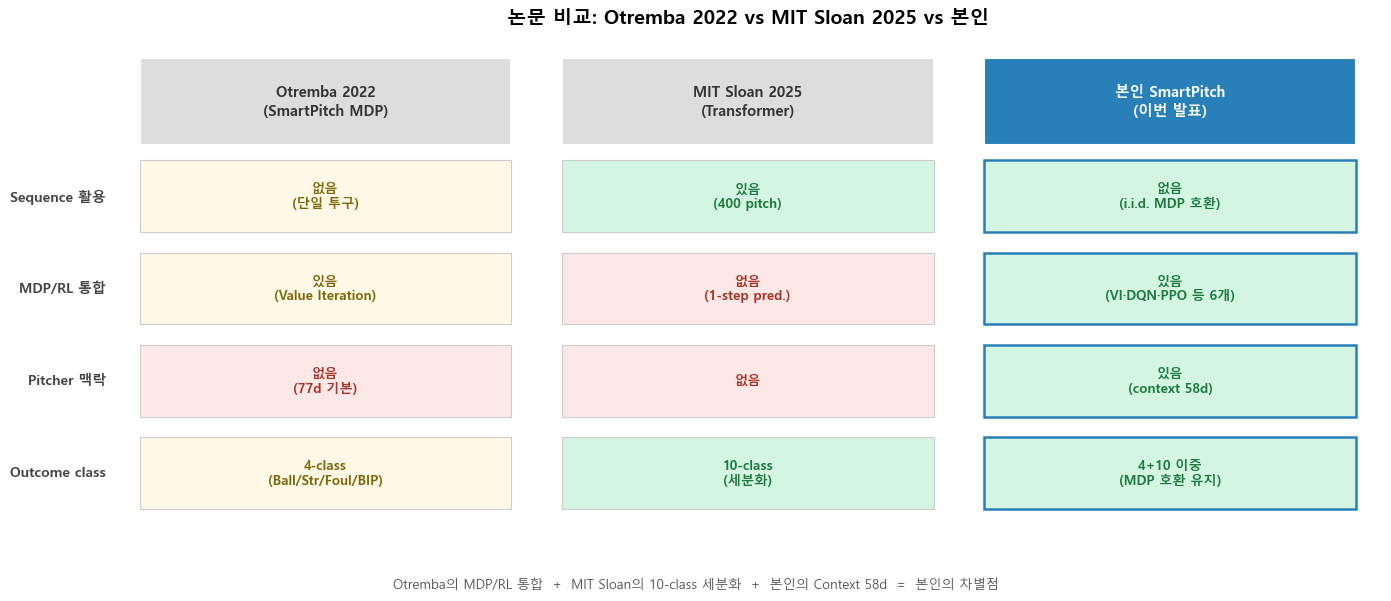

[OK] fig2_paper_positioning.png 재생성 완료


In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_xlim(0, 3)
ax.set_ylim(0, 1)
ax.axis('off')

# ── 레이아웃 상수 ────────────────────────────────────────────────────────────
COL_X   = [0.5, 1.5, 2.5]
COL_W   = 0.88
HEADER_Y = 0.90
ROW_Y   = [0.70, 0.52, 0.34, 0.16]
ROW_H   = 0.14

HEADERS = ['Otremba 2022\n(SmartPitch MDP)', 'MIT Sloan 2025\n(Transformer)', '본인 SmartPitch\n(이번 발표)']
ROWS    = ['Sequence 활용', 'MDP/RL 통합', 'Pitcher 맥락', 'Outcome class']

COL_COLORS = ['#f9f9f9', '#f9f9f9', '#e8f4fd']
HEADER_BG  = ['#dddddd', '#dddddd', '#2980b9']
HEADER_FG  = ['#333333', '#333333', 'white']

# ── 셀 데이터 [row][col] ─────────────────────────────────────────────────────
CELLS = [
    # row 0: Sequence 활용
    [('없음\n(단일 투구)', 'neu'), ('있음\n(400 pitch)', 'pos'), ('없음\n(i.i.d. MDP 호환)', 'pos')],
    # row 1: MDP/RL 통합
    [('있음\n(Value Iteration)', 'neu'),
     ('없음\n(1-step pred.)', 'neg'),
     ('있음\n(VI·DQN·PPO 등 6개)', 'pos')],
    # row 2: Pitcher 맥락
    [('없음\n(77d 기본)', 'neg'), ('없음', 'neg'), ('있음\n(context 58d)', 'pos')],
    # row 3: Outcome class
    [('4-class\n(Ball/Str/Foul/BIP)', 'neu'),
     ('10-class\n(세분화)', 'pos'),
     ('4+10 이중\n(MDP 호환 유지)', 'pos')],
]

COLOR_MAP = {'pos': '#d5f5e3', 'neg': '#fde8e8', 'neu': '#fef9e7'}
TEXT_MAP  = {'pos': '#1a7a3e', 'neg': '#a93226', 'neu': '#7d6608'}

# ── 행 라벨 ────────────────────────────────────────────────────────────────
for ry, label in zip(ROW_Y, ROWS):
    ax.text(-0.02, ry, label, transform=ax.transData,
            ha='right', va='center', fontsize=10, fontweight='bold', color='#444444')

# ── 헤더 ───────────────────────────────────────────────────────────────────
for ci, (cx, txt, bg, fg) in enumerate(zip(COL_X, HEADERS, HEADER_BG, HEADER_FG)):
    rect = plt.Rectangle(
        (cx - COL_W/2, HEADER_Y - 0.10), COL_W, 0.17,
        facecolor=bg, edgecolor='white', linewidth=1.5, transform=ax.transData, zorder=3
    )
    ax.add_patch(rect)
    ax.text(cx, HEADER_Y - 0.015, txt, ha='center', va='center',
            fontsize=10.5, fontweight='bold', color=fg, zorder=4)

# ── 셀 ─────────────────────────────────────────────────────────────────────
for ri, (ry, row) in enumerate(zip(ROW_Y, CELLS)):
    for ci, (cx, (txt, hint)) in enumerate(zip(COL_X, row)):
        bg = COLOR_MAP[hint]
        if ci == 2:
            ec, ew = '#2980b9', 1.8
        else:
            ec, ew = '#cccccc', 0.8
        rect = plt.Rectangle(
            (cx - COL_W/2, ry - ROW_H/2), COL_W, ROW_H,
            facecolor=bg, edgecolor=ec, linewidth=ew, transform=ax.transData, zorder=3
        )
        ax.add_patch(rect)
        ax.text(cx, ry, txt, ha='center', va='center',
                fontsize=9.5, color=TEXT_MAP[hint], fontweight='bold', zorder=4)

ax.set_title(
    '논문 비교: Otremba 2022 vs MIT Sloan 2025 vs 본인',
    fontsize=14, fontweight='bold', pad=14
)

# 하단 결론 한 줄
fig.text(0.5, 0.01,
         'Otremba의 MDP/RL 통합  +  MIT Sloan의 10-class 세분화  +  본인의 Context 58d  =  본인의 차별점',
         ha='center', fontsize=9.5, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(FIG_DIR / 'fig2_paper_positioning.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('[OK] fig2_paper_positioning.png 재생성 완료')


## Figure 3 (백업): 4-class MDP/DQN 호환 그룹

4-class 실측값:
  Logistic Regression       Top-1=56.3%  Macro-F1=48.4%
  LightGBM                  Top-1=60.8%  Macro-F1=53.3%
  MLP (Model B) ★ MDP 권장    Top-1=60.9%  Macro-F1=53.8%


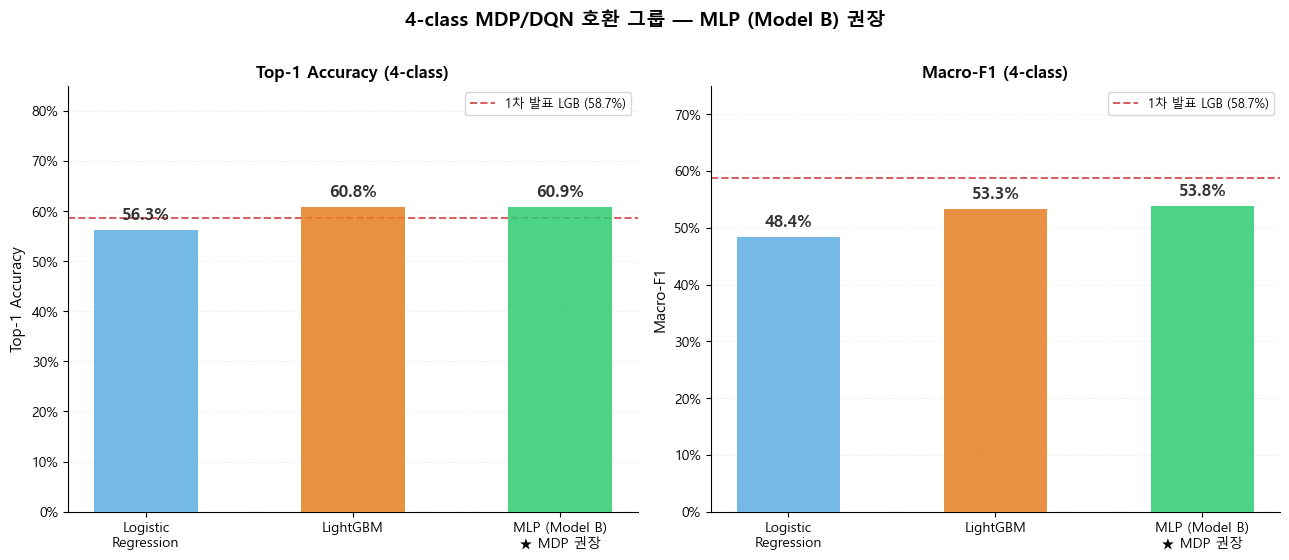

[OK] fig3_4class_mdp.png 저장됨


In [4]:
# 실측값 (outputs/all_models_comparison_4cls.json)
names4   = ['Logistic\nRegression', 'LightGBM', 'MLP (Model B)\n★ MDP 권장']
top1_4   = [comp4['Logistic Regression']['top1'],
            comp4['LightGBM']['top1'],
            comp4['MLP (Model B)']['top1']]
mf1_4    = [comp4['Logistic Regression']['macro_f1'],
            comp4['LightGBM']['macro_f1'],
            comp4['MLP (Model B)']['macro_f1']]
colors4  = ['#5dade2', '#e67e22', '#2ecc71']

print('4-class 실측값:')
for n, t, m in zip(names4, top1_4, mf1_4):
    print(f'  {n.replace(chr(10)," "):<25} Top-1={t*100:.1f}%  Macro-F1={m*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

REF_LINE = 0.587  # 1차 발표 LightGBM baseline
BASELINE = 0.25   # random 4-class baseline

for ax, vals, ylabel, title, ylim in [
    (axes[0], top1_4, 'Top-1 Accuracy', 'Top-1 Accuracy (4-class)', 0.85),
    (axes[1], mf1_4,  'Macro-F1',        'Macro-F1 (4-class)',        0.75),
]:
    bars = ax.bar(names4, vals, color=colors4, alpha=0.85, width=0.5, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.012,
            f'{v*100:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333'
        )
    # 1차 발표 기준선
    ax.axhline(REF_LINE, color='#cc3333', linestyle='--', linewidth=1.4,
               alpha=0.8, label='1차 발표 LGB (58.7%)')
    ax.set_ylim(0, ylim)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9)

fig.suptitle(
    '4-class MDP/DQN 호환 그룹 — MLP (Model B) 권장',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_4class_mdp.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('[OK] fig3_4class_mdp.png 저장됨')

## Figure 4: Top-4 Precision — Per-class 히트맵 (MIT Sloan 평가 기준)

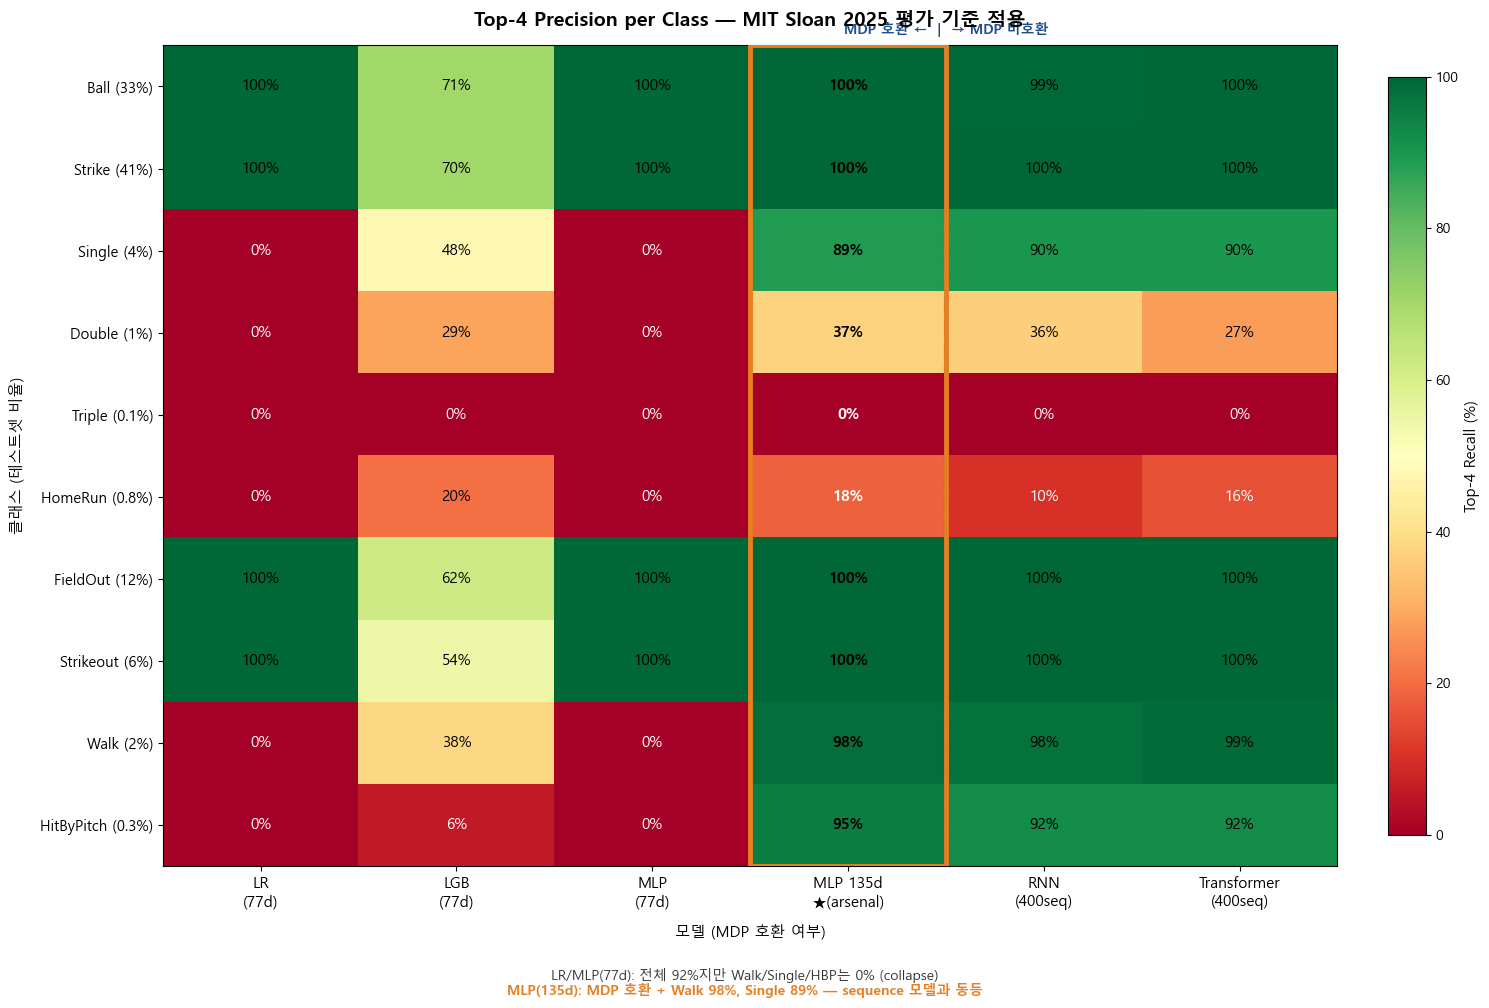

[OK] fig4_top4_precision_heatmap.png 저장됨


In [5]:
import json
import numpy as np
from pathlib import Path

with open(OUTPUT_DIR / 'top4_precision_comparison.json', encoding='utf-8') as f:
    top4_data = json.load(f)

CLASSES_10 = ["Ball", "Strike", "Single", "Double", "Triple",
               "HomeRun", "FieldOut", "Strikeout", "Walk", "HitByPitch"]
CLASS_PCT = {
    "Ball": 33.3, "Strike": 41.1, "Single": 3.6, "Double": 1.1,
    "Triple": 0.09, "HomeRun": 0.81, "FieldOut": 11.8,
    "Strikeout": 5.9, "Walk": 2.0, "HitByPitch": 0.28,
}
MODEL_ORDER  = ["LR", "LightGBM", "MLP (77d)", "MLP (135d)", "RNN", "Transformer"]
MODEL_LABELS = ["LR\n(77d)", "LGB\n(77d)", "MLP\n(77d)", "MLP 135d\n★(arsenal)", "RNN\n(400seq)", "Transformer\n(400seq)"]

def fmt_pct(p):
    return f'{p:.1f}%' if p < 1 else f'{round(p)}%'

mat = np.full((len(CLASSES_10), len(MODEL_ORDER)), np.nan)
for mi, mname in enumerate(MODEL_ORDER):
    if mname not in top4_data:
        continue
    pc = top4_data[mname].get("per_class", {})
    for ci, cname in enumerate(CLASSES_10):
        v = pc.get(cname)
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            mat[ci, mi] = v * 100

# ── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')

im = ax.imshow(mat, cmap=plt.cm.RdYlGn, vmin=0, vmax=100, aspect='auto')

# 셀 텍스트
for ci in range(len(CLASSES_10)):
    for mi in range(len(MODEL_ORDER)):
        val = mat[ci, mi]
        if np.isnan(val):
            txt, col = '-', '#888888'
        else:
            txt = f'{val:.0f}%'
            col = 'black' if 20 < val < 80 else ('white' if val <= 20 else 'black')
        fw = 'bold' if mi == 3 else 'normal'
        ax.text(mi, ci, txt, ha='center', va='center', fontsize=11, color=col, fontweight=fw)

# ── Y축: 한 줄 라벨, 1% 미만은 소수점 1자리 ────────────────────────────────
ax.set_yticks(range(len(CLASSES_10)))
y_labels = [f'{c} ({fmt_pct(CLASS_PCT[c])})' for c in CLASSES_10]
ax.set_yticklabels(y_labels, fontsize=10.5)

# ── X축 ────────────────────────────────────────────────────────────────────
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_LABELS, fontsize=11)

# ── MDP 구분선 (히트맵 내부, MLP135d와 RNN 사이) ────────────────────────────
ax.axvline(3.5, color='#1f4e8c', linewidth=3, linestyle='--', alpha=0.85, zorder=5)
ax.text(3.5, -0.6, 'MDP 호환 ←  |  → MDP 비호환',
        ha='center', va='bottom', fontsize=10, color='#1f4e8c', fontweight='bold',
        transform=ax.transData)

# ── MLP 135d 열 전체 박스 (한 번, 셀 루프 X) ────────────────────────────────
ax.add_patch(plt.Rectangle(
    (2.5, -0.5), 1, len(CLASSES_10),
    fill=False, edgecolor='#e67e22', linewidth=3.5, zorder=10
))

# ── 컬러바 ─────────────────────────────────────────────────────────────────
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Top-4 Recall (%)', fontsize=11)
cbar.ax.tick_params(labelsize=10)

# ── 제목 ───────────────────────────────────────────────────────────────────
ax.set_title(
    'Top-4 Precision per Class — MIT Sloan 2025 평가 기준 적용',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('모델 (MDP 호환 여부)', fontsize=11, labelpad=10)
ax.set_ylabel('클래스 (테스트셋 비율)', fontsize=11, labelpad=10)

# ── 하단 요약 (히트맵 바로 아래, 한글 통일) ────────────────────────────────
fig.text(0.5, 0.015,
         'LR/MLP(77d): 전체 92%지만 Walk/Single/HBP는 0% (collapse)',
         ha='center', fontsize=10, color='#333333')
fig.text(0.5, 0.00,
         'MLP(135d): MDP 호환 + Walk 98%, Single 89% — sequence 모델과 동등',
         ha='center', fontsize=10, color='#e67e22', fontweight='bold')

plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(FIG_DIR / 'fig4_top4_precision_heatmap.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('[OK] fig4_top4_precision_heatmap.png 저장됨')


## 저장 확인

In [6]:
for fname in ['fig1_arsenal_vs_sequence.png', 'fig2_paper_positioning.png',
               'fig3_4class_mdp.png', 'fig4_top4_precision_heatmap.png']:
    p = FIG_DIR / fname
    status = f'{p.stat().st_size / 1024:.0f} KB' if p.exists() else 'NOT FOUND'
    print(f'  {fname}: {status}')

  fig1_arsenal_vs_sequence.png: 333 KB
  fig2_paper_positioning.png: 230 KB
  fig3_4class_mdp.png: 200 KB
  fig4_top4_precision_heatmap.png: 411 KB
